In [1]:
pip install pandas numpy faker scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 22.7 MB/s eta 0:00:00


In [2]:
# ============================================
# Social Media Engagement Prediction Project
# Synthetic Data + Full ML Pipeline
# ============================================

import pandas as pd
import numpy as np
from faker import Faker
import random

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
random.seed(42)

In [7]:
# ============================================
# STEP 1 — Synthetic Dataset Generation
# ============================================

def generate_synthetic_data(n_samples=1200):

    faker = Faker()

    data = {
        "Post_ID": [faker.uuid4() for _ in range(n_samples)],

        "Post_Type": [random.choice(["Image","Video","Text","Mixed"]) for _ in range(n_samples)],

        "Hashtags": [random.randint(0,20) for _ in range(n_samples)],

        "Words_Count": [random.randint(5,300) for _ in range(n_samples)],

        "Likes": [max(0,int(np.random.normal(500,200))) for _ in range(n_samples)],

        "Shares": [max(0,int(np.random.normal(50,20))) for _ in range(n_samples)],

        "Comments": [max(0,int(np.random.normal(30,15))) for _ in range(n_samples)],

        "Views": [max(0,int(np.random.normal(1200,500))) for _ in range(n_samples)],

        "Follower_Count": [max(1,int(np.random.normal(10000,4000))) for _ in range(n_samples)],

        "Account_Age": [random.randint(1,10) for _ in range(n_samples)],

        "User_Type": [random.choice(["Influencer","Brand","Casual_User"]) for _ in range(n_samples)],

        "Sentiment_Score": [round(random.uniform(-1,1),2) for _ in range(n_samples)],

        "Time_of_Post": [random.choice(["Morning","Afternoon","Evening","Night"]) for _ in range(n_samples)],

        "Day_of_Week": [random.choice(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]) for _ in range(n_samples)],

        "Engagement_Level": [random.choice(["High","Low"]) for _ in range(n_samples)]
    }

    df = pd.DataFrame(data)

    # Introduce inconsistencies

    # Missing numeric values
    df.loc[random.sample(range(n_samples),int(n_samples*0.1)),"Likes"] = None

    # Missing categorical values
    df.loc[random.sample(range(n_samples),int(n_samples*0.05)),"Post_Type"] = None

    # Duplicate rows
    df = pd.concat([df,df.sample(frac=0.1,replace=True)])

    return df


data = generate_synthetic_data()

In [8]:
# ============================================
# STEP 2 — Inspect Raw Data Issues
# ============================================

print("\nMissing Values BEFORE preprocessing")
print(data.isnull().sum())

print("\nDuplicate Rows BEFORE preprocessing")
print(data[data.duplicated()].head())


Missing Values BEFORE preprocessing
Post_ID               0
Post_Type            68
Hashtags              0
Words_Count           0
Likes               135
Shares                0
Comments              0
Views                 0
Follower_Count        0
Account_Age           0
User_Type             0
Sentiment_Score       0
Time_of_Post          0
Day_of_Week           0
Engagement_Level      0
dtype: int64

Duplicate Rows BEFORE preprocessing
                                   Post_ID Post_Type  Hashtags  Words_Count  \
559   eddd3009-5bf5-4338-b3a1-c100a1cea8e1     Mixed        18           43   
348   ff79a00f-02f4-4373-a25e-498c51068738      None        12          145   
1090  376e5df3-3d36-4799-836c-af05049150a2     Image         9          255   
329   cabc7941-1f9f-48fe-831c-268048ee2edd     Video        11           62   
193   a8186271-3b4a-4621-9008-10c86fcb5da2     Mixed         5          137   

      Likes  Shares  Comments  Views  Follower_Count  Account_Age  \
559   435

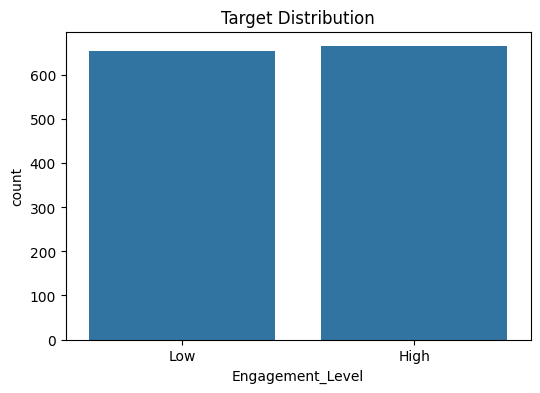

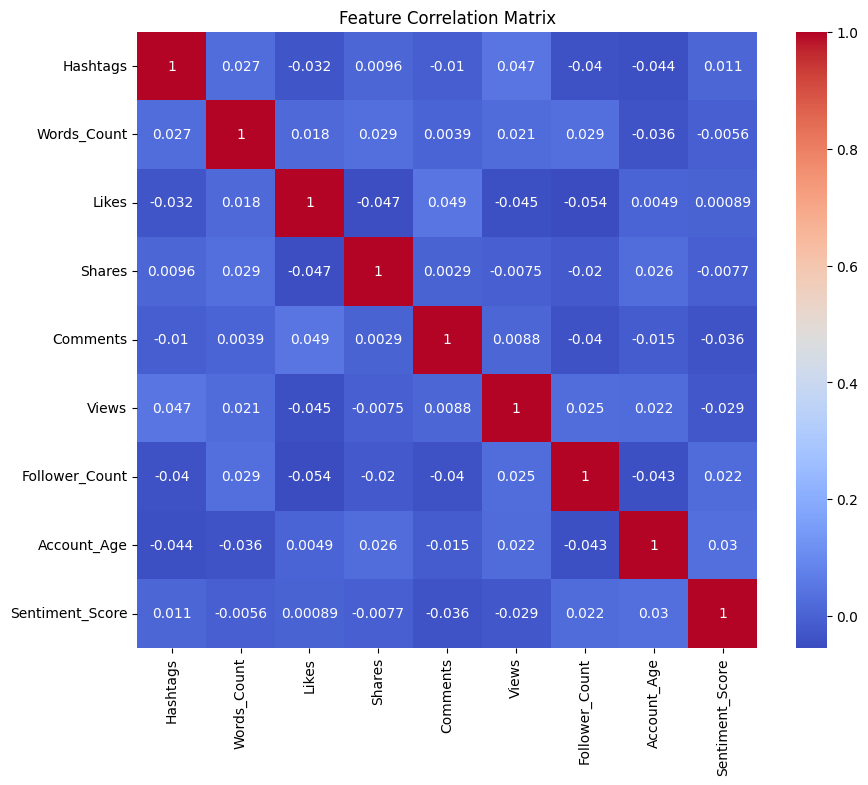

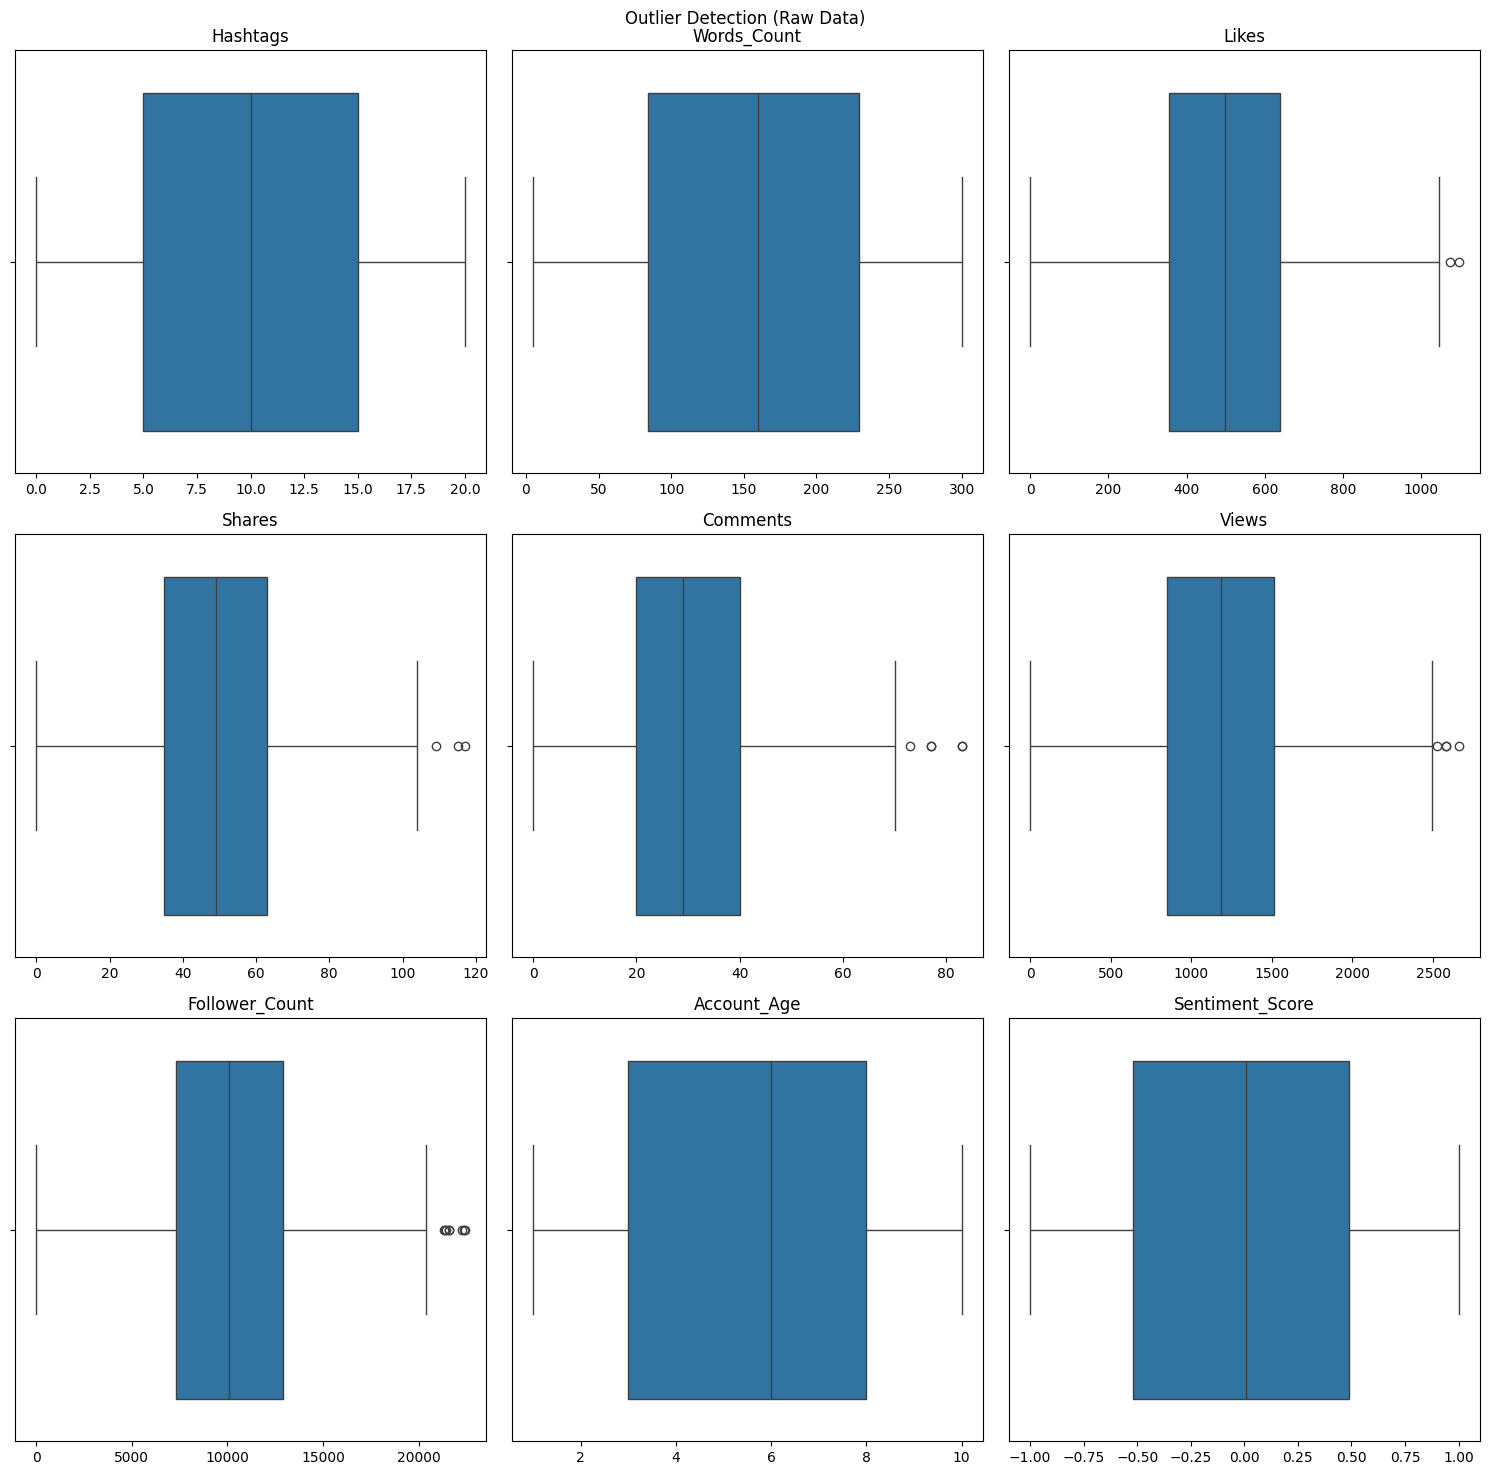

In [10]:
# ============================================
# STEP 3 — Exploratory Data Analysis
# ============================================

numerical_features = [
"Hashtags","Words_Count","Likes","Shares",
"Comments","Views","Follower_Count",
"Account_Age","Sentiment_Score"
]

# Distribution

plt.figure(figsize=(6,4))
sns.countplot(x="Engagement_Level",data=data)
plt.title("Target Distribution")
plt.show()

# Correlation matrix

plt.figure(figsize=(10,8))
sns.heatmap(data[numerical_features].corr(),annot=True,cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

# Outlier detection

fig,axes = plt.subplots(3,3,figsize=(15,15))

for i,feature in enumerate(numerical_features):

    # Use values to avoid pandas reindexing issues if duplicate labels exist
    sns.boxplot(x=data[feature].dropna().values, ax=axes[i//3, i%3])
    axes[i//3,i%3].set_title(feature)

plt.suptitle("Outlier Detection (Raw Data)")
plt.tight_layout()
plt.show()


In [14]:
# ============================================
# STEP 4 — Feature Engineering
# ============================================

# Engagement Rate

data["Engagement_Rate"] = (
    data["Likes"] + data["Shares"] + data["Comments"]
) / data["Views"]

# Replace infinite values caused by division by zero

data["Engagement_Rate"] = data["Engagement_Rate"].replace([np.inf, -np.inf], np.nan)

# Hashtag Density

data["Hashtag_Density"] = data["Hashtags"] / data["Words_Count"]

# Influence Score

data["Influence_Score"] = data["Follower_Count"] * data["Account_Age"]

In [15]:
# ============================================
# STEP 5 — Train Model on RAW Data
# ============================================

raw_data = data.copy()

raw_y = raw_data["Engagement_Level"]
raw_X = raw_data.drop(columns=["Engagement_Level","Post_ID"])

raw_X_train,raw_X_test,raw_y_train,raw_y_test = train_test_split(
    raw_X,raw_y,test_size=0.2,random_state=42
)

# quick imputation for raw experiment

raw_X_train["Likes"] = raw_X_train["Likes"].fillna(raw_X_train["Likes"].mean())
raw_X_test["Likes"] = raw_X_test["Likes"].fillna(raw_X_test["Likes"].mean())

raw_X_train["Post_Type"] = raw_X_train["Post_Type"].fillna(raw_X_train["Post_Type"].mode()[0])
raw_X_test["Post_Type"] = raw_X_test["Post_Type"].fillna(raw_X_test["Post_Type"].mode()[0])

# encode categorical

enc_cols=["Post_Type","Day_of_Week","User_Type","Time_of_Post"]
encoders={}

for col in enc_cols:

    le=LabelEncoder()
    raw_X_train[col]=le.fit_transform(raw_X_train[col])
    raw_X_test[col]=le.transform(raw_X_test[col])

    encoders[col]=le

raw_model=RandomForestClassifier(random_state=42)

raw_model.fit(raw_X_train,raw_y_train)

raw_pred=raw_model.predict(raw_X_test)

print("\nRAW MODEL PERFORMANCE")

print("Accuracy:",accuracy_score(raw_y_test,raw_pred))
print(classification_report(raw_y_test,raw_pred))



RAW MODEL PERFORMANCE
Accuracy: 0.5643939393939394
              precision    recall  f1-score   support

        High       0.59      0.55      0.57       139
         Low       0.54      0.58      0.56       125

    accuracy                           0.56       264
   macro avg       0.57      0.57      0.56       264
weighted avg       0.57      0.56      0.56       264



In [16]:
# ============================================
# STEP 6 — Preprocessing Pipeline
# ============================================

clean_data = data.copy()

# Remove duplicates

print("\nDuplicates BEFORE dropping:",clean_data.duplicated().sum())

clean_data = clean_data.drop_duplicates()

print("Duplicates AFTER dropping:",clean_data.duplicated().sum())

# Missing value handling

clean_data["Likes"] = clean_data["Likes"].fillna(clean_data["Likes"].mean())
clean_data["Post_Type"] = clean_data["Post_Type"].fillna(clean_data["Post_Type"].mode()[0])

# Drop less important features

clean_data = clean_data.drop(columns=["User_Type","Time_of_Post"])


Duplicates BEFORE dropping: 120
Duplicates AFTER dropping: 0


In [17]:
# ============================================
# STEP 7 — Train Model on CLEAN Data
# ============================================


y = clean_data["Engagement_Level"]
X = clean_data.drop(columns=["Engagement_Level","Post_ID"])

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

# Encode

cat_cols=["Post_Type","Day_of_Week"]

encoders={}

for col in cat_cols:

    le=LabelEncoder()
    X_train[col]=le.fit_transform(X_train[col])
    X_test[col]=le.transform(X_test[col])

    encoders[col]=le

# Scale

num_cols=[
"Hashtags","Words_Count","Likes","Shares",
"Comments","Views","Follower_Count",
"Account_Age","Sentiment_Score",
"Engagement_Rate","Hashtag_Density","Influence_Score"
]

scaler=StandardScaler()

X_train[num_cols]=scaler.fit_transform(X_train[num_cols])
X_test[num_cols]=scaler.transform(X_test[num_cols])

# Train

model=RandomForestClassifier(random_state=42)

model.fit(X_train,y_train)

pred=model.predict(X_test)

print("\nCLEAN MODEL PERFORMANCE")

print("Accuracy:",accuracy_score(y_test,pred))
print(classification_report(y_test,pred))


CLEAN MODEL PERFORMANCE
Accuracy: 0.4791666666666667
              precision    recall  f1-score   support

        High       0.51      0.54      0.52       127
         Low       0.44      0.42      0.43       113

    accuracy                           0.48       240
   macro avg       0.48      0.48      0.48       240
weighted avg       0.48      0.48      0.48       240




Cross Validation Accuracy: 0.465625


/tmp/ipykernel_178/1868286099.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances,y=feature_names,palette="viridis")


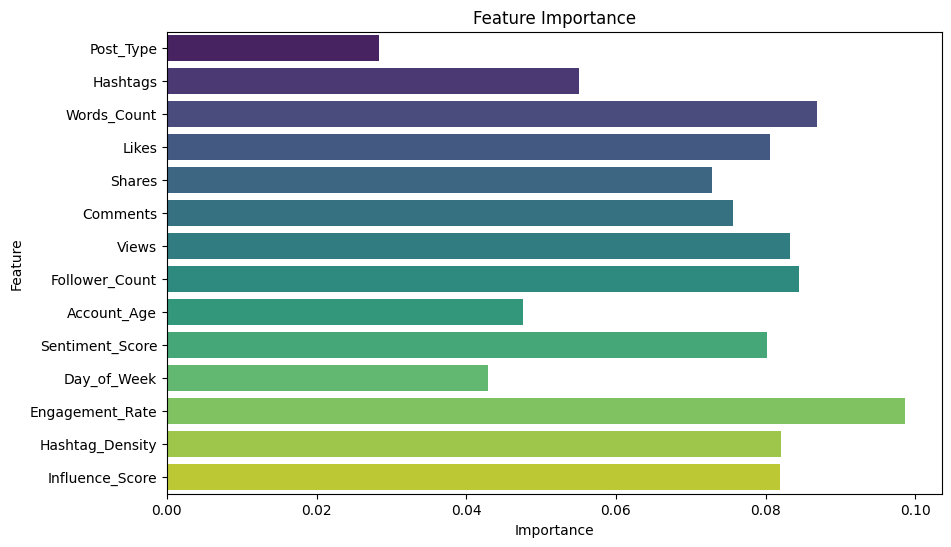

In [18]:
# ============================================
# STEP 8 — Cross Validation
# ============================================

scores = cross_val_score(model,X_train,y_train,cv=5)

print("\nCross Validation Accuracy:",scores.mean())

# ============================================
# STEP 9 — Feature Importance
# ============================================

importances = model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importances,y=feature_names,palette="viridis")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

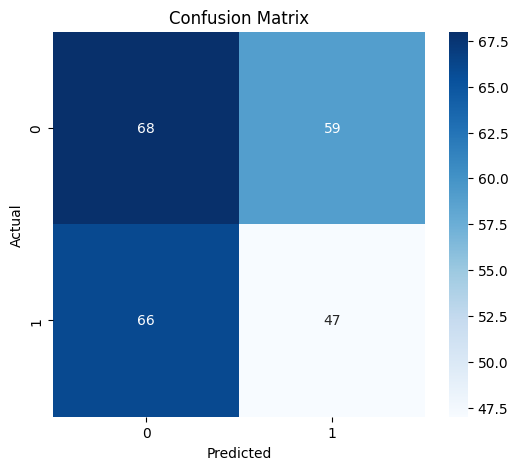

In [19]:
# ============================================
# STEP 10 — Confusion Matrix
# ============================================

cm = confusion_matrix(y_test,pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [20]:
# ============================================
# STEP 11 — Save Dataset
# ============================================

clean_data.to_csv("synthetic_social_media_data.csv",index=False)

In [1]:












# ============================================
# STEP 6 — Preprocessing Pipeline
# ============================================

clean_data = data.copy()

# Remove duplicates

print("\nDuplicates BEFORE dropping:",clean_data.duplicated().sum())

clean_data = clean_data.drop_duplicates()

print("Duplicates AFTER dropping:",clean_data.duplicated().sum())

# Missing value handling

clean_data["Likes"].fillna(clean_data["Likes"].mean(),inplace=True)
clean_data["Post_Type"].fillna(clean_data["Post_Type"].mode()[0],inplace=True)

# Drop less important features

clean_data = clean_data.drop(columns=["User_Type","Time_of_Post"])

# ============================================
# STEP 7 — Train Model on CLEAN Data
# ============================================


y = clean_data["Engagement_Level"]
X = clean_data.drop(columns=["Engagement_Level","Post_ID"])

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

# Encode

cat_cols=["Post_Type","Day_of_Week"]

encoders={}

for col in cat_cols:

    le=LabelEncoder()
    X_train[col]=le.fit_transform(X_train[col])
    X_test[col]=le.transform(X_test[col])

    encoders[col]=le

# Scale

num_cols=[
"Hashtags","Words_Count","Likes","Shares",
"Comments","Views","Follower_Count",
"Account_Age","Sentiment_Score",
"Engagement_Rate","Hashtag_Density","Influence_Score"
]

scaler=StandardScaler()

X_train[num_cols]=scaler.fit_transform(X_train[num_cols])
X_test[num_cols]=scaler.transform(X_test[num_cols])

# Train

model=RandomForestClassifier(random_state=42)

model.fit(X_train,y_train)

pred=model.predict(X_test)

print("\nCLEAN MODEL PERFORMANCE")

print("Accuracy:",accuracy_score(y_test,pred))
print(classification_report(y_test,pred))

# ============================================
# STEP 8 — Cross Validation
# ============================================

scores = cross_val_score(model,X_train,y_train,cv=5)

print("\nCross Validation Accuracy:",scores.mean())

# ============================================
# STEP 9 — Feature Importance
# ============================================

importances = model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importances,y=feature_names,palette="viridis")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# ============================================
# STEP 10 — Confusion Matrix
# ============================================

cm = confusion_matrix(y_test,pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# ============================================
# STEP 11 — Save Dataset
# ============================================

clean_data.to_csv("synthetic_social_media_data.csv",index=False)


ModuleNotFoundError: No module named 'faker'